In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Reproductibilité 
np.random.seed(42)

# Paramètres
n_points = 500 # nombre de mesures
temps = np.arange(n_points) 

# Signaux normaux (basés sur les paramètres réels fed-batch)
pH = np.random.normal(loc = 7.0, scale = 0.05, size = n_points)
temperature = np.random.normal(loc = 37.0, scale = 0.2, size = n_points)
D0 = np.random.normal(loc = 35.0, scale = 1.0, size = n_points) #oxygène dissous en pourcentage

# Injection d'anomalies à partir du point 350
pH[350:] = np.random.normal(loc = 6.2, scale = 0.1, size = 150)  # dérive pH
temperature[400:] = np.random.normal(loc = 39.5, scale = 0.3, size = 100)  # pic température
D0[370:] = np.random.normal(loc = 20.0, scale = 2.0, size = 130)  # chute d'oxygène

# Création du dataframe
df = pd.DataFrame({
    'temps': temps,
    'pH': pH,
    'temperature': temperature,
    'D0': D0
})

print(df.head(10))
print(df.shape)



   temps        pH  temperature         D0
0      0  7.024836    37.185236  36.399355
1      1  6.993087    37.381883  35.924634
2      2  7.032384    36.720286  35.059630
3      3  7.076151    37.112594  34.353063
4      4  6.988292    36.869871  35.698223
5      5  6.988293    36.902575  35.393485
6      6  7.078961    36.881521  35.895193
7      7  7.038372    36.827202  35.635172
8      8  6.976526    37.009704  36.049553
9      9  7.027128    36.833810  34.464765
(500, 4)


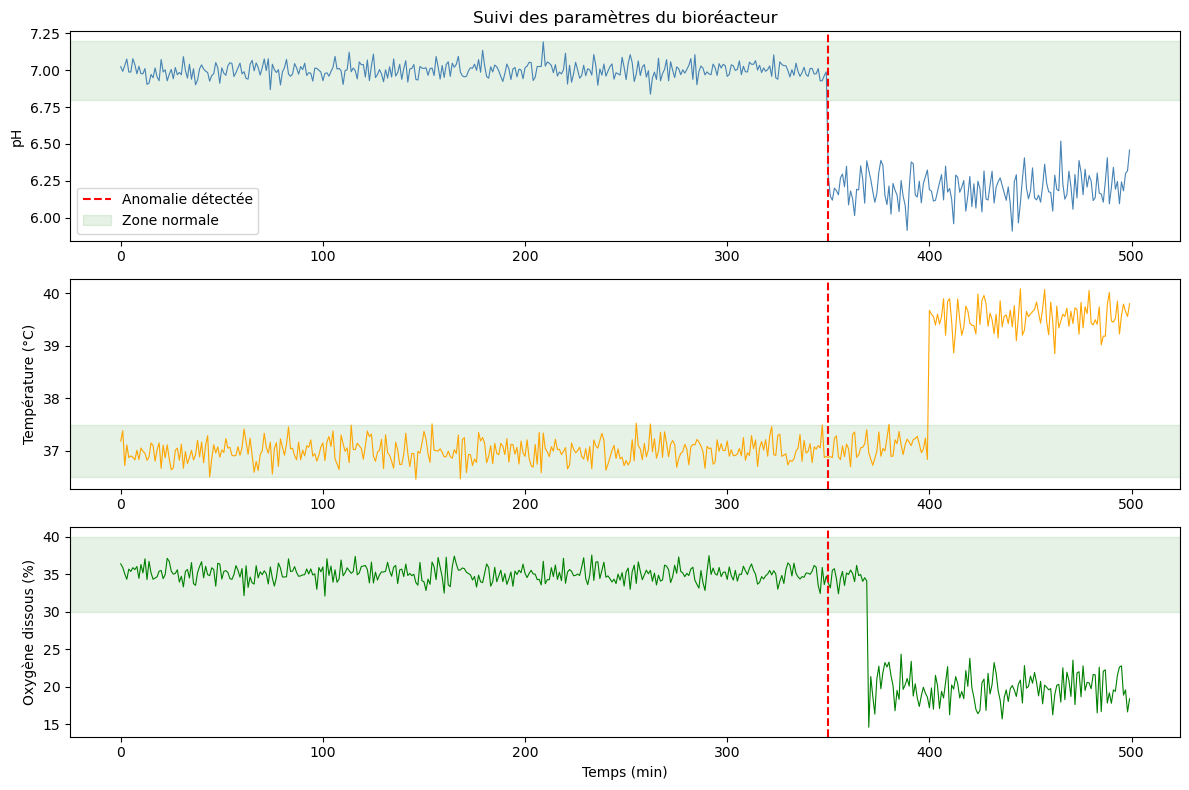

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Graphique pH
axes[0].plot(df['temps'], df['pH'], color='steelblue', linewidth=0.8)
axes[0].axvline(x=350, color='red', linestyle='--', label='Anomalie détectée')
axes[0].axhspan(6.8, 7.2, alpha=0.1, color='green', label='Zone normale')
axes[0].set_ylabel('pH')
axes[0].set_title('Suivi des paramètres du bioréacteur')
axes[0].legend()

# Graphique Température
axes[1].plot(df['temps'], df['temperature'], color='orange', linewidth=0.8)
axes[1].axvline(x=350, color='red', linestyle='--')
axes[1].axhspan(36.5, 37.5, alpha=0.1, color='green')
axes[1].set_ylabel('Température (°C)')

# Graphique DO
axes[2].plot(df['temps'], df['D0'], color='green', linewidth=0.8)
axes[2].axvline(x=350, color='red', linestyle='--')
axes[2].axhspan(30, 40, alpha=0.1, color='green')
axes[2].set_ylabel('Oxygène dissous (%)')
axes[2].set_xlabel('Temps (min)')

plt.tight_layout()
plt.show()

In [8]:
# Définition des seuils normaux
seuils = {
    'pH': (6.8, 7.2),
    'temperature': (36.5, 37.5),
    'D0': (30.0, 40.0)
}

# Détection des anomalies
df['anomalie_pH'] = (df['pH'] < seuils['pH'][0]) | (df['pH'] > seuils['pH'][1])
df['anomalie_temp'] = (df['temperature'] < seuils['temperature'][0]) | (df['temperature'] > seuils['temperature'][1])
df['anomalie_D0'] = (df['D0'] < seuils['D0'][0]) | (df['D0'] > seuils['D0'][1])

# Anomalie globale (au moins un capteur en anomalie)
df['anomalie_globale'] = df['anomalie_pH'] | df['anomalie_temp'] | df['anomalie_D0']

# Résumé
print("=== RAPPORT D'ANOMALIES ===")
print(f"Points anormaux pH       : {df['anomalie_pH'].sum()}")
print(f"Points anormaux Temp     : {df['anomalie_temp'].sum()}")
print(f"Points anormaux D0       : {df['anomalie_D0'].sum()}")
print(f"Total points anormaux    : {df['anomalie_globale'].sum()}")
print(f"Premier point anormal    : t = {df[df['anomalie_globale']].index[0]} min")

=== RAPPORT D'ANOMALIES ===
Points anormaux pH       : 150
Points anormaux Temp     : 106
Points anormaux D0       : 130
Total points anormaux    : 155
Premier point anormal    : t = 146 min


In [10]:
# On calcule la moyenne mobile sur une fenêtre de 10 points
df['pH_lisse'] = df['pH'].rolling(window=10).mean()
df['temp_lisse'] = df['temperature'].rolling(window=10).mean()
df['D0_lisse'] = df['D0'].rolling(window=10).mean()

# On recalcule les anomalies sur les signaux lissés
df['anomalie_pH_robuste'] = (df['pH_lisse'] < 6.8) | (df['pH_lisse'] > 7.2)

# Comparaison
print(f"Premier point anormal (Brut)   : t = {df[df['anomalie_pH']].index[0]} min")
# On gère les NaN créés par le rolling au début
df_clean = df.dropna()
print(f"Premier point anormal (Lissé) : t = {df_clean[df_clean['anomalie_pH_robuste']].index[0]} min")

Premier point anormal (Brut)   : t = 350 min
Premier point anormal (Lissé) : t = 352 min


In [11]:
def diagnostic(row):
    causes = []
    if row['anomalie_pH']: causes.append("Dérive pH (Contamination possible ?)")
    if row['anomalie_temp']: causes.append("Surchauffe (Panne système de refroidissement ?)")
    if row['anomalie_D0']: causes.append("Chute O2 (Problème d'agitation/débit d'air ?)")
    return " & ".join(causes) if causes else "Normal"

# On applique le diagnostic sur le premier point critique détecté
premier_instant = df_clean[df_clean['anomalie_pH_robuste']].index[0]
info_alerte = df_clean.loc[premier_instant]

print(f"--- RAPPORT DE CRISE ---")
print(f"Heure de l'alerte : {premier_instant} min")
print(f"Diagnostic : {diagnostic(info_alerte)}")
print(f"Valeurs au moment de l'alerte : pH={info_alerte['pH_lisse']:.2f}, Temp={info_alerte['temp_lisse']:.2f}°C")

--- RAPPORT DE CRISE ---
Heure de l'alerte : 352 min
Diagnostic : Dérive pH (Contamination possible ?)
Valeurs au moment de l'alerte : pH=6.73, Temp=37.02°C


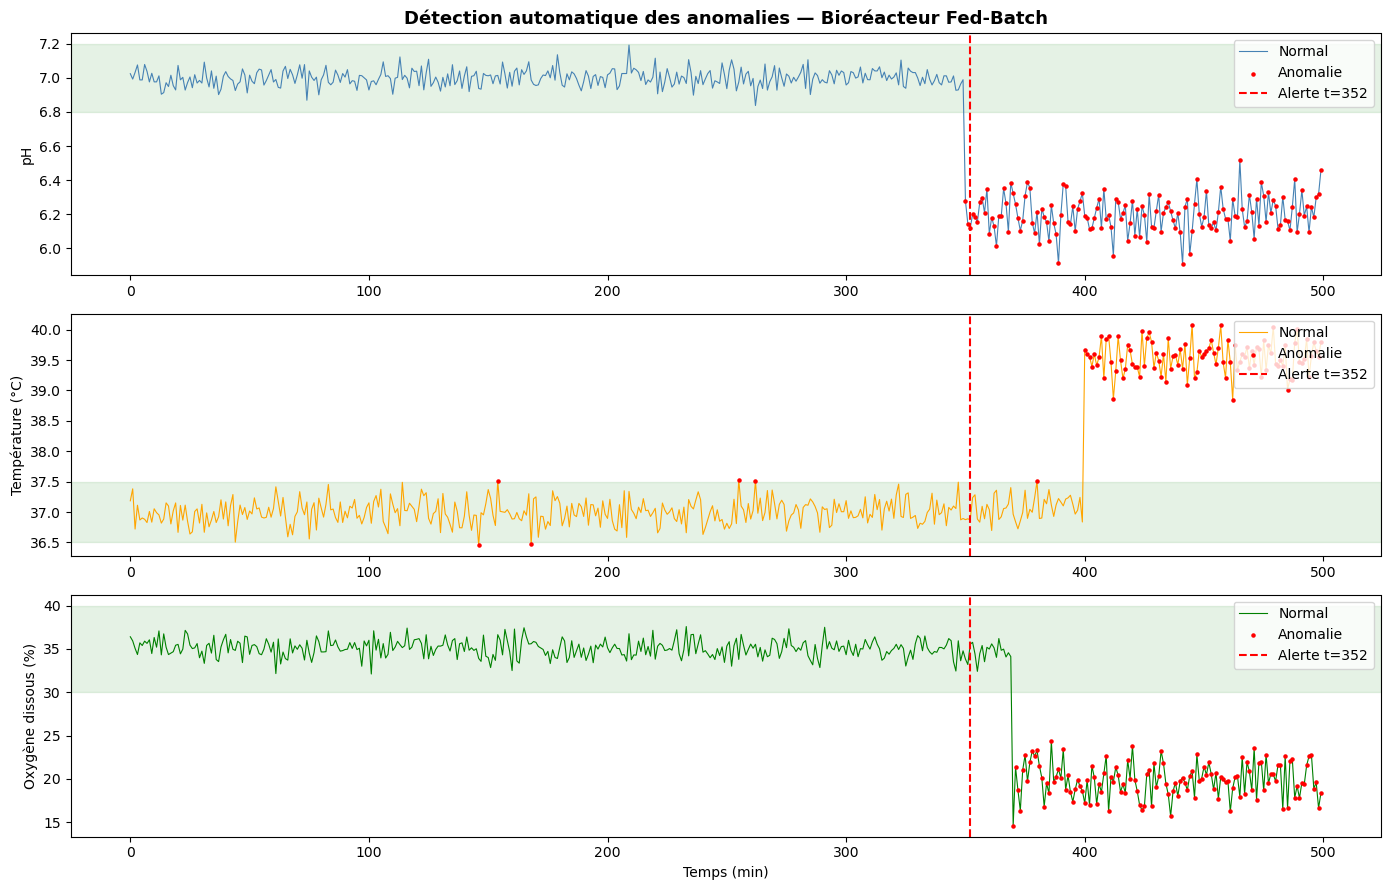

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

capteurs = [
    ('pH', 'anomalie_pH', 'steelblue', (6.8, 7.2), 'pH'),
    ('temperature', 'anomalie_temp', 'orange', (36.5, 37.5), 'Température (°C)'),
    ('D0', 'anomalie_D0', 'green', (30.0, 40.0), 'Oxygène dissous (%)')
]

for i, (col, anomalie_col, couleur, seuils, ylabel) in enumerate(capteurs):
    
    # Signal normal
    axes[i].plot(df['temps'], df[col], 
                 color=couleur, linewidth=0.8, label='Normal')
    
    # Points anormaux en rouge
    axes[i].scatter(df[df[anomalie_col]]['temps'],
                    df[df[anomalie_col]][col],
                    color='red', s=5, label='Anomalie', zorder=5)
    
    # Zone normale
    axes[i].axhspan(seuils[0], seuils[1], 
                    alpha=0.1, color='green')
    
    # Ligne de détection lissée
    axes[i].axvline(x=352, color='red', 
                    linestyle='--', linewidth=1.5, label='Alerte t=352')
    
    axes[i].set_ylabel(ylabel)
    axes[i].legend(loc='upper right')

axes[0].set_title('Détection automatique des anomalies — Bioréacteur Fed-Batch', 
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Temps (min)')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()